In [2]:
import sys
from pathlib import Path

# Ajustar el path del proyecto para importar el módulo desde src/
project_root = Path.cwd()
while project_root != project_root.parent and not (project_root / "src").exists():
    project_root = project_root.parent

if not (project_root / "src").exists():
    raise FileNotFoundError("No se encontró la carpeta 'src' en el árbol de directorios.")

# Importante: insertar la raíz del proyecto, no la carpeta src.
sys.path.insert(0, str(project_root.resolve()))
print("project_root:", project_root)
print("sys.path[0]:", sys.path[0])

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from astropy import units as u
from astropy.coordinates import SkyCoord

try:
    from IPython.display import display
except ImportError:
    display = print
import importlib
import src.vector_director as vd
importlib.reload(vd)
from src.vector_director import run_cluster_analysis_from_dataframe
KM_S_PER_ARCSEC_YR_PC = 4.74047
MAS_TO_RAD = np.deg2rad(1.0 / 3_600_000.0)
KM_S_PER_AU_YR = 4.74047

project_root: c:\Users\nicob\One Drive Uniandes\OneDrive - Universidad de los Andes\Doctorado\proyecto\clusterization_project
sys.path[0]: C:\Users\nicob\One Drive Uniandes\OneDrive - Universidad de los Andes\Doctorado\proyecto\clusterization_project


In [3]:
def unit_vector_to_galactic_lb(vector: np.ndarray) -> dict:
    """
    Convierte un vector cartesiano galáctico 3D a coordenadas l, b.

    Parameters
    ----------
    vector : np.ndarray
        Vector 3D en coordenadas galácticas cartesianas.

    Returns
    -------
    dict
        Diccionario con l_deg, b_deg, l_rad, b_rad.
    """

    vector = np.asarray(vector, dtype=float)
    norm = np.linalg.norm(vector)

    if norm == 0.0:
        raise ValueError("Input vector has zero norm.")

    unit_vector = vector / norm

    x_coord, y_coord, z_coord = unit_vector

    l_rad = np.arctan2(y_coord, x_coord) % (2.0 * np.pi)
    b_rad = np.arcsin(np.clip(z_coord, -1.0, 1.0))

    return {
        "l_deg": np.degrees(l_rad),
        "b_deg": np.degrees(b_rad),
        "l_rad": l_rad,
        "b_rad": b_rad,
    }


def extract_cross_product_apex_candidates(
    analysis_result: dict,
    use_refined: bool = True,
    weight_col: str | None = None,
    pole_x_col: str = "pole_x_unit",
    pole_y_col: str = "pole_y_unit",
    pole_z_col: str = "pole_z_unit",
    min_cross_norm: float = 1e-12,
) -> pd.DataFrame:
    """
    Extrae todos los candidatos a ápex generados por productos cruzados
    entre pares de polos.

    Parameters
    ----------
    analysis_result : dict
        Resultado devuelto por `process_single_cluster`.

    use_refined : bool, optional
        Si True, usa el DataFrame refinado si existe.

    weight_col : str or None, optional
        Columna de pesos. Por ejemplo: "probabilidad".

    pole_x_col, pole_y_col, pole_z_col : str
        Columnas con los polos unitarios.

    min_cross_norm : float
        Norma mínima aceptada para el producto cruz entre dos polos.

    Returns
    -------
    pd.DataFrame
        Tabla con candidatos:

        - apex_l_deg
        - apex_b_deg
        - candidate_weight
        - cross_norm
        - i
        - j
    """

    if use_refined and "df_refined" in analysis_result:
        df = analysis_result["df_refined"].copy()
        apex_result = analysis_result.get("apex_refined")
    else:
        df = analysis_result["df_initial"].copy()
        apex_result = analysis_result.get("apex_initial")

    if apex_result is None or "error" in apex_result:
        apex_result = analysis_result["apex_result"]

    reference_apex_vector = np.asarray(
        apex_result["apex_vector"],
        dtype=float,
    )
    reference_apex_vector = (
        reference_apex_vector / np.linalg.norm(reference_apex_vector)
    )

    required_cols = [pole_x_col, pole_y_col, pole_z_col]

    for col in required_cols:
        if col not in df.columns:
            raise ValueError(f"Missing required column: {col}")

    poles = df[[pole_x_col, pole_y_col, pole_z_col]].to_numpy(dtype=float)

    valid = np.isfinite(poles).all(axis=1)
    pole_norms = np.linalg.norm(poles, axis=1)
    valid &= pole_norms > 0.0

    df_valid = df.loc[valid].copy()
    poles = poles[valid] / pole_norms[valid, None]

    if weight_col is not None and weight_col in df_valid.columns:
        weights = df_valid[weight_col].to_numpy(dtype=float)
        weights = np.where(np.isfinite(weights) & (weights > 0.0), weights, 1.0)
    else:
        weights = np.ones(len(df_valid), dtype=float)

    candidates = []

    n_poles = len(poles)

    for i in range(n_poles):
        for j in range(i + 1, n_poles):
            cross_vector = np.cross(poles[i], poles[j])
            cross_norm = np.linalg.norm(cross_vector)

            if cross_norm <= min_cross_norm:
                continue

            candidate_vector = cross_vector / cross_norm

            # Orientar hacia el mismo hemisferio que el ápex estimado.
            if np.dot(candidate_vector, reference_apex_vector) < 0.0:
                candidate_vector = -candidate_vector

            coords = unit_vector_to_galactic_lb(candidate_vector)

            candidate_weight = weights[i] * weights[j] * cross_norm

            candidates.append(
                {
                    "i": i,
                    "j": j,
                    "apex_l_deg": coords["l_deg"],
                    "apex_b_deg": coords["b_deg"],
                    "candidate_weight": candidate_weight,
                    "cross_norm": cross_norm,
                }
            )

    if len(candidates) == 0:
        raise ValueError("No valid cross-product apex candidates found.")

    return pd.DataFrame(candidates)


def get_lambda_values_from_result(
    analysis_result: dict,
    use_refined: bool = True,
) -> np.ndarray:
    """
    Extrae los valores de lambda_deg desde el resultado del análisis.
    """

    if use_refined and "df_refined" in analysis_result:
        df = analysis_result["df_refined"]
    else:
        df = analysis_result["df_initial"]

    if "lambda_deg_refined" in df.columns:
        lambda_values = df["lambda_deg_refined"].to_numpy(dtype=float)
    elif "lambda_deg_initial" in df.columns:
        lambda_values = df["lambda_deg_initial"].to_numpy(dtype=float)
    elif "lambda_deg" in df.columns:
        lambda_values = df["lambda_deg"].to_numpy(dtype=float)
    else:
        raise ValueError(
            "No lambda column found. Expected lambda_deg, "
            "lambda_deg_initial or lambda_deg_refined."
        )

    return lambda_values[np.isfinite(lambda_values)]

def place_legend_outside(
    ax: plt.Axes,
    loc: str = "upper left",
) -> None:
    """
    Coloca la leyenda fuera del eje para evitar que se solape
    con las cajas de estadísticas o con los datos.
    """

    handles, labels = ax.get_legend_handles_labels()

    if len(handles) == 0:
        return

    ax.legend(
        handles,
        labels,
        loc=loc,
        bbox_to_anchor=(1.02, 1.0),
        borderaxespad=0.0,
        frameon=True,
        framealpha=0.9,
        fontsize=8,
    )


def wrap_angle_deg(angle_deg: np.ndarray) -> np.ndarray:
    """
    Lleva ángulos en grados al intervalo [-180, 180).
    """

    return (angle_deg + 180.0) % 360.0 - 180.0


def weighted_quantile(
    values: np.ndarray,
    quantiles: list[float],
    weights: np.ndarray | None = None,
) -> np.ndarray:
    """
    Calcula cuantiles ponderados.

    Parameters
    ----------
    values : np.ndarray
        Valores de entrada.

    quantiles : list[float]
        Cuantiles entre 0 y 1.

    weights : np.ndarray or None
        Pesos. Si es None, usa cuantiles no ponderados.

    Returns
    -------
    np.ndarray
        Cuantiles solicitados.
    """

    values = np.asarray(values, dtype=float)
    quantiles = np.asarray(quantiles, dtype=float)

    valid = np.isfinite(values)

    if weights is None:
        return np.quantile(values[valid], quantiles)

    weights = np.asarray(weights, dtype=float)
    valid &= np.isfinite(weights)
    valid &= weights > 0.0

    values = values[valid]
    weights = weights[valid]

    if len(values) == 0:
        return np.full_like(quantiles, np.nan, dtype=float)

    sorter = np.argsort(values)
    values = values[sorter]
    weights = weights[sorter]

    cumulative_weights = np.cumsum(weights)
    cumulative_weights /= cumulative_weights[-1]

    return np.interp(quantiles, cumulative_weights, values)


def weighted_mean_and_std(
    values: np.ndarray,
    weights: np.ndarray | None = None,
) -> tuple[float, float]:
    """
    Media y desviación estándar ponderadas.
    """

    values = np.asarray(values, dtype=float)
    valid = np.isfinite(values)

    if weights is None:
        clean_values = values[valid]
        return float(np.mean(clean_values)), float(np.std(clean_values))

    weights = np.asarray(weights, dtype=float)
    valid &= np.isfinite(weights)
    valid &= weights > 0.0

    clean_values = values[valid]
    clean_weights = weights[valid]

    mean = np.average(clean_values, weights=clean_weights)
    variance = np.average(
        (clean_values - mean) ** 2,
        weights=clean_weights,
    )

    return float(mean), float(np.sqrt(variance))


def weighted_circular_mean_and_std_deg(
    angles_deg: np.ndarray,
    weights: np.ndarray | None = None,
) -> tuple[float, float]:
    """
    Media circular y desviación circular para ángulos en grados.

    Útil para longitud galáctica l, porque l = 359° y l = 1°
    están cerca angularmente.
    """

    angles_deg = np.asarray(angles_deg, dtype=float)
    valid = np.isfinite(angles_deg)

    if weights is None:
        clean_weights = np.ones(valid.sum(), dtype=float)
    else:
        weights = np.asarray(weights, dtype=float)
        valid &= np.isfinite(weights)
        valid &= weights > 0.0
        clean_weights = weights[valid]

    clean_angles_rad = np.deg2rad(angles_deg[valid])

    sin_mean = np.average(np.sin(clean_angles_rad), weights=clean_weights)
    cos_mean = np.average(np.cos(clean_angles_rad), weights=clean_weights)

    mean_rad = np.arctan2(sin_mean, cos_mean) % (2.0 * np.pi)

    resultant_length = np.sqrt(sin_mean**2 + cos_mean**2)
    resultant_length = np.clip(resultant_length, 1e-15, 1.0)

    std_rad = np.sqrt(-2.0 * np.log(resultant_length))

    return float(np.rad2deg(mean_rad)), float(np.rad2deg(std_rad))


def galactic_lb_to_unit_vectors(
    l_deg: np.ndarray,
    b_deg: np.ndarray,
) -> np.ndarray:
    """
    Convierte coordenadas galácticas l, b a vectores cartesianos unitarios.
    """

    l_rad = np.deg2rad(l_deg)
    b_rad = np.deg2rad(b_deg)

    x_coord = np.cos(l_rad) * np.cos(b_rad)
    y_coord = np.sin(l_rad) * np.cos(b_rad)
    z_coord = np.sin(b_rad)

    return np.column_stack((x_coord, y_coord, z_coord))


def angular_separation_deg(
    vectors_a: np.ndarray,
    vector_b: np.ndarray,
) -> np.ndarray:
    """
    Calcula separación angular entre muchos vectores y un vector de referencia.
    """

    vectors_a = np.asarray(vectors_a, dtype=float)
    vector_b = np.asarray(vector_b, dtype=float)

    vectors_a = vectors_a / np.linalg.norm(vectors_a, axis=1)[:, None]
    vector_b = vector_b / np.linalg.norm(vector_b)

    cos_angle = np.clip(vectors_a @ vector_b, -1.0, 1.0)

    return np.rad2deg(np.arccos(cos_angle))


def add_stats_box(
    ax: plt.Axes,
    text: str,
    loc: str = "upper right",
) -> None:
    """
    Agrega una caja de texto con estadísticas dentro de un eje.
    """

    positions = {
        "upper right": (0.97, 0.97, "right", "top"),
        "upper left": (0.03, 0.97, "left", "top"),
        "lower right": (0.97, 0.03, "right", "bottom"),
        "lower left": (0.03, 0.03, "left", "bottom"),
    }

    x_pos, y_pos, ha_text, va_text = positions[loc]

    ax.text(
        x_pos,
        y_pos,
        text,
        transform=ax.transAxes,
        ha=ha_text,
        va=va_text,
        fontsize=9,
        bbox={
            "boxstyle": "round",
            "facecolor": "white",
            "alpha": 0.82,
            "edgecolor": "gray",
        },
    )


def plot_apex_candidate_diagnostics(
    analysis_result: dict,
    true_apex_l_deg: float | None = None,
    true_apex_b_deg: float | None = None,
    use_refined: bool = True,
    weight_col: str | None = None,
    bins_l: int = 40,
    bins_b: int = 40,
    bins_lambda: int = 40,
    bins_residual: int = 40,
    figsize: tuple[float, float] = (14.0, 9.0),
) -> tuple[plt.Figure, np.ndarray, object]:
    """
    Grafica diagnósticos de candidatos a ápex por producto cruz.

    Incluye:

    1. Histograma ponderado de l de candidatos.
    2. Histograma ponderado de b de candidatos.
    3. Histograma de lambda de las estrellas.
    4. Histograma del residuo angular de candidatos respecto al ápex.

    Parameters
    ----------
    analysis_result : dict
        Salida de `process_single_cluster`.

    true_apex_l_deg : float or None
        Longitud galáctica verdadera del ápex simulado, en grados.

    true_apex_b_deg : float or None
        Latitud galáctica verdadera del ápex simulado, en grados.

    use_refined : bool
        Si True, usa el resultado refinado.

    weight_col : str or None
        Columna de pesos para los candidatos.

    Returns
    -------
    tuple
        fig, axes, candidates_df.
    """

    candidates_df = extract_cross_product_apex_candidates(
        analysis_result=analysis_result,
        use_refined=use_refined,
        weight_col=weight_col,
    )

    lambda_values = get_lambda_values_from_result(
        analysis_result=analysis_result,
        use_refined=use_refined,
    )

    if use_refined and "apex_refined" in analysis_result:
        apex_result = analysis_result["apex_refined"]
    else:
        apex_result = analysis_result["apex_initial"]

    if apex_result is None or "error" in apex_result:
        apex_result = analysis_result["apex_result"]

    estimated_l = float(apex_result["apex_l_deg"])
    estimated_b = float(apex_result["apex_b_deg"])

    weights = candidates_df["candidate_weight"].to_numpy(dtype=float)

    candidate_vectors = galactic_lb_to_unit_vectors(
        candidates_df["apex_l_deg"].to_numpy(dtype=float),
        candidates_df["apex_b_deg"].to_numpy(dtype=float),
    )

    estimated_vector = np.asarray(apex_result["apex_vector"], dtype=float)

    residual_to_estimated = angular_separation_deg(
        candidate_vectors,
        estimated_vector,
    )

    candidates_df["residual_to_estimated_deg"] = residual_to_estimated

    if true_apex_l_deg is not None and true_apex_b_deg is not None:
        true_vector = galactic_lb_to_unit_vectors(
            np.array([true_apex_l_deg]),
            np.array([true_apex_b_deg]),
        )[0]

        residual_to_true = angular_separation_deg(
            candidate_vectors,
            true_vector,
        )

        candidates_df["residual_to_true_deg"] = residual_to_true
        residual_values = residual_to_true
        residual_label = "Residuo angular respecto al ápex verdadero [deg]"
    else:
        residual_values = residual_to_estimated
        residual_label = "Residuo angular respecto al ápex estimado [deg]"

    l_values = candidates_df["apex_l_deg"].to_numpy(dtype=float)
    b_values = candidates_df["apex_b_deg"].to_numpy(dtype=float)

    l_mean, l_std = weighted_circular_mean_and_std_deg(l_values, weights)
    b_mean, b_std = weighted_mean_and_std(b_values, weights)

    residual_mean, residual_std = weighted_mean_and_std(
        residual_values,
        weights,
    )

    residual_q16, residual_q50, residual_q84 = weighted_quantile(
        residual_values,
        [0.16, 0.50, 0.84],
        weights,
    )

    lambda_mean, lambda_std = weighted_mean_and_std(lambda_values)
    lambda_q16, lambda_q50, lambda_q84 = weighted_quantile(
        lambda_values,
        [0.16, 0.50, 0.84],
    )

    l_delta_to_estimated = wrap_angle_deg(l_values - estimated_l)
    l_delta_mean, l_delta_std = weighted_mean_and_std(
        l_delta_to_estimated,
        weights,
    )

    if true_apex_l_deg is not None:
        delta_l_true = wrap_angle_deg(np.array([estimated_l - true_apex_l_deg]))
        delta_l_true = float(delta_l_true[0])
    else:
        delta_l_true = np.nan

    if true_apex_b_deg is not None:
        delta_b_true = estimated_b - true_apex_b_deg
    else:
        delta_b_true = np.nan

    fig, axes = plt.subplots(
        nrows=2,
        ncols=2,
        figsize=figsize,
        constrained_layout=True,
    )

    ax_l = axes[0, 0]
    ax_b = axes[0, 1]
    ax_lambda = axes[1, 0]
    ax_residual = axes[1, 1]

    ax_l.hist(
        l_values,
        bins=bins_l,
        weights=weights,
        color="tab:blue",
        alpha=0.75,
        edgecolor="black",
    )

    ax_l.axvline(
        estimated_l,
        color="tab:red",
        linestyle="--",
        linewidth=2,
        label=f"Estimado: {estimated_l:.2f}°",
    )

    ax_l.axvline(
        l_mean,
        color="tab:orange",
        linestyle=":",
        linewidth=2,
        label=f"Media circ.: {l_mean:.2f}°",
    )

    if true_apex_l_deg is not None:
        ax_l.axvline(
            true_apex_l_deg,
            color="black",
            linestyle="-",
            linewidth=2,
            label=f"Verdadero: {true_apex_l_deg:.2f}°",
        )

    ax_l.set_xlabel("l del candidato a ápex [deg]")
    ax_l.set_ylabel("Frecuencia ponderada")
    ax_l.set_title("Distribución de l")
    ax_l.legend(loc=1)

    l_stats = (
        f"N candidatos = {len(candidates_df)}\n"
        f"media circ. = {l_mean:.2f}°\n"
        f"std circ. = {l_std:.2f}°\n"
        f"Δl vs estimado = {l_delta_mean:.2f} ± {l_delta_std:.2f}°"
    )

    if np.isfinite(delta_l_true):
        l_stats += f"\nΔl estimado-true = {delta_l_true:.2f}°"

    add_stats_box(ax_l, l_stats, loc="upper left")

    ax_b.hist(
        b_values,
        bins=bins_b,
        weights=weights,
        color="tab:green",
        alpha=0.75,
        edgecolor="black",
    )

    ax_b.axvline(
        estimated_b,
        color="tab:red",
        linestyle="--",
        linewidth=2,
        label=f"Estimado: {estimated_b:.2f}°",
    )

    ax_b.axvline(
        b_mean,
        color="tab:orange",
        linestyle=":",
        linewidth=2,
        label=f"Media: {b_mean:.2f}°",
    )

    if true_apex_b_deg is not None:
        ax_b.axvline(
            true_apex_b_deg,
            color="black",
            linestyle="-",
            linewidth=2,
            label=f"Verdadero: {true_apex_b_deg:.2f}°",
        )

    ax_b.set_xlabel("b del candidato a ápex [deg]")
    ax_b.set_ylabel("Frecuencia ponderada")
    ax_b.set_title("Distribución de b")
    ax_b.legend(loc=1)

    b_stats = (
        f"media = {b_mean:.2f}°\n"
        f"std = {b_std:.2f}°\n"
        f"estimado = {estimated_b:.2f}°"
    )

    if np.isfinite(delta_b_true):
        b_stats += f"\nΔb estimado-true = {delta_b_true:.2f}°"

    add_stats_box(ax_b, b_stats, loc="upper left")

    ax_lambda.hist(
        lambda_values,
        bins=bins_lambda,
        color="tab:purple",
        alpha=0.75,
        edgecolor="black",
    )

    ax_lambda.axvline(
        lambda_q50,
        color="tab:red",
        linestyle="--",
        linewidth=2,
        label=f"Mediana: {lambda_q50:.2f}°",
    )

    ax_lambda.axvspan(
        lambda_q16,
        lambda_q84,
        color="tab:red",
        alpha=0.15,
        label="p16-p84",
    )

    ax_lambda.set_xlabel(r"$\lambda$ [deg]")
    ax_lambda.set_ylabel("Número de estrellas")
    ax_lambda.set_title(r"Distribución de $\lambda$")
    ax_lambda.legend(loc = 1)

    lambda_stats = (
        f"N estrellas = {len(lambda_values)}\n"
        f"media = {lambda_mean:.2f}°\n"
        f"std = {lambda_std:.2f}°\n"
        f"p16-p50-p84 = "
        f"{lambda_q16:.2f}, {lambda_q50:.2f}, {lambda_q84:.2f}°"
    )

    add_stats_box(ax_lambda, lambda_stats, loc="upper left")

    ax_residual.hist(
        residual_values,
        bins=bins_residual,
        weights=weights,
        color="tab:brown",
        alpha=0.75,
        edgecolor="black",
    )

    ax_residual.axvline(
        residual_q50,
        color="tab:red",
        linestyle="--",
        linewidth=2,
        label=f"Mediana: {residual_q50:.2f}°",
    )

    ax_residual.axvspan(
        residual_q16,
        residual_q84,
        color="tab:red",
        alpha=0.15,
        label="p16-p84",
    )

    ax_residual.set_xlabel(residual_label)
    ax_residual.set_ylabel("Frecuencia ponderada")
    ax_residual.set_title("Residuo angular de candidatos")
    ax_residual.legend(loc=2)

    residual_stats = (
        f"media = {residual_mean:.2f}°\n"
        f"std = {residual_std:.2f}°\n"
        f"mediana = {residual_q50:.2f}°\n"
        f"p16-p84 = {residual_q16:.2f}–{residual_q84:.2f}°"
    )

    add_stats_box(ax_residual, residual_stats, loc="upper right")

    title_suffix = "refinado" if use_refined else "inicial"

    fig.suptitle(
        f"Diagnóstico del ápex por producto cruz ({title_suffix})",
        fontsize=15,
    )

    return fig, axes, candidates_df

In [4]:
# ============================================================
# Basic vector utilities
# ============================================================

def normalize_vectors(vectors, axis=1):
    vectors = np.asarray(vectors, dtype=float)
    norms = np.linalg.norm(vectors, axis=axis)

    if axis == 1:
        out = np.full_like(vectors, np.nan, dtype=float)
        valid = norms > 0
        out[valid] = vectors[valid] / norms[valid, None]
        return out, norms

    if axis == 0:
        if norms == 0:
            return np.full_like(vectors, np.nan), norms
        return vectors / norms, norms

    raise ValueError("axis must be 0 or 1.")

# ============================================================
# Core astrometric diagnostics
# ============================================================


def angular_separation_vectors_deg(v1, v2):
    v1 = np.asarray(v1, dtype=float)
    v2 = np.asarray(v2, dtype=float)

    v1 = v1 / np.linalg.norm(v1)
    v2 = v2 / np.linalg.norm(v2)

    cosang = np.clip(np.dot(v1, v2), -1.0, 1.0)
    return np.degrees(np.arccos(cosang))

def add_cluster_apex_diagnostics_icrs(
    df,
    apex_vector_icrs,
    weight_col="probabilidad",
    min_pole_norm=0.0,
):
    """
    Diagnósticos astrométricos en sistema ICRS/Gaia.

    Required columns:
        ra, dec, parallax, pmra, pmdec

    Optional:
        weight_col
        radial_velocity_kms_true
        radial_velocity
    """

    required = ["ra", "dec", "parallax", "pmra", "pmdec"]
    missing = [col for col in required if col not in df.columns]

    if missing:
        raise ValueError(f"Missing required columns: {missing}")

    result_df = df.copy()

    if weight_col is None or weight_col not in result_df.columns:
        result_df["_weight_used"] = np.ones(len(result_df), dtype=float)
        result_df["_weight_used"] /= result_df["_weight_used"].sum()
    else:
        weights = result_df[weight_col].to_numpy(dtype=float)
        weights = np.where(np.isfinite(weights) & (weights > 0), weights, 0.0)

        if np.sum(weights) <= 0:
            weights = np.ones(len(result_df), dtype=float)

        result_df["_weight_used"] = weights / np.sum(weights)

    ra_rad = np.deg2rad(result_df["ra"].to_numpy(dtype=float))
    dec_rad = np.deg2rad(result_df["dec"].to_numpy(dtype=float))

    pmra = result_df["pmra"].to_numpy(dtype=float)
    pmdec = result_df["pmdec"].to_numpy(dtype=float)

    cos_dec = np.cos(dec_rad)
    safe_cos_dec = np.where(np.abs(cos_dec) > 1e-12, cos_dec, np.nan)

    # ------------------------------------------------------------
    # Vector unitario de posición en ICRS
    # ------------------------------------------------------------

    star_vec = np.column_stack(
        (
            np.cos(dec_rad) * np.cos(ra_rad),
            np.cos(dec_rad) * np.sin(ra_rad),
            np.sin(dec_rad),
        )
    )

    result_df["x_icrs"] = star_vec[:, 0]
    result_df["y_icrs"] = star_vec[:, 1]
    result_df["z_icrs"] = star_vec[:, 2]

    # ------------------------------------------------------------
    # Posición final tras 1 año de movimiento propio
    # Gaia: pmra = mu_alpha* = mu_alpha cos(dec)
    # Por tanto: delta_ra = pmra / cos(dec)
    # ------------------------------------------------------------

    delta_ra_rad = (pmra / safe_cos_dec) * MAS_TO_RAD
    delta_dec_rad = pmdec * MAS_TO_RAD

    ra2_rad = (ra_rad + delta_ra_rad) % (2.0 * np.pi)
    dec2_rad = dec_rad + delta_dec_rad

    star_vec_final = np.column_stack(
        (
            np.cos(dec2_rad) * np.cos(ra2_rad),
            np.cos(dec2_rad) * np.sin(ra2_rad),
            np.sin(dec2_rad),
        )
    )

    poles = np.cross(star_vec, star_vec_final)
    poles_hat, pole_norm = normalize_vectors(poles, axis=1)

    valid_pole = np.isfinite(pole_norm) & (pole_norm > min_pole_norm)
    valid_pole &= np.all(np.isfinite(poles_hat), axis=1)

    result_df["pole_x"] = poles_hat[:, 0]
    result_df["pole_y"] = poles_hat[:, 1]
    result_df["pole_z"] = poles_hat[:, 2]
    result_df["pole_norm"] = pole_norm
    result_df["valid_pole"] = valid_pole

    # ------------------------------------------------------------
    # Lambda respecto al ápex ICRS
    # ------------------------------------------------------------

    apex_vector_icrs = np.asarray(apex_vector_icrs, dtype=float)
    apex_vector_icrs = apex_vector_icrs / np.linalg.norm(apex_vector_icrs)

    cos_lambda = np.clip(star_vec @ apex_vector_icrs, -1.0, 1.0)
    sin_lambda = np.sqrt(np.clip(1.0 - cos_lambda**2, 0.0, 1.0))

    lambda_rad = np.arctan2(sin_lambda, cos_lambda)

    result_df["cos_lambda"] = cos_lambda
    result_df["sin_lambda"] = sin_lambda
    result_df["lambda_deg"] = np.degrees(lambda_rad)

    # ------------------------------------------------------------
    # Residuos del polo respecto al plano perpendicular al ápex
    # ------------------------------------------------------------

    dot_pole_apex = np.full(len(result_df), np.nan)
    dot_pole_apex[valid_pole] = poles_hat[valid_pole] @ apex_vector_icrs

    pole_residual_rad = np.arcsin(
        np.clip(np.abs(dot_pole_apex), 0.0, 1.0)
    )

    result_df["pole_residual_deg"] = np.degrees(pole_residual_rad)

    # ------------------------------------------------------------
    # Movimiento propio total y velocidad tangencial
    # ------------------------------------------------------------

    mu_tot = np.sqrt(pmra**2 + pmdec**2)
    result_df["mu_total_masyr"] = mu_tot

    parallax = result_df["parallax"].to_numpy(dtype=float)

    distance_pc = np.full(len(result_df), np.nan)
    valid_parallax = parallax > 0
    distance_pc[valid_parallax] = 1000.0 / parallax[valid_parallax]

    result_df["distance_pc_from_parallax"] = distance_pc

    result_df["vt_kms"] = (
        KM_S_PER_AU_YR
        * (mu_tot / 1000.0)
        * distance_pc
    )

    # ------------------------------------------------------------
    # Alineación entre movimiento propio observado y dirección al ápex
    # en el plano tangente ecuatorial
    # ------------------------------------------------------------

    e_ra = np.column_stack(
        (
            -np.sin(ra_rad),
            np.cos(ra_rad),
            np.zeros_like(ra_rad),
        )
    )

    e_dec = np.column_stack(
        (
            -np.cos(ra_rad) * np.sin(dec_rad),
            -np.sin(ra_rad) * np.sin(dec_rad),
            np.cos(dec_rad),
        )
    )

    motion_tangent = pmra[:, None] * e_ra + pmdec[:, None] * e_dec
    motion_norm = np.linalg.norm(motion_tangent, axis=1)

    apex_tangent = apex_vector_icrs[None, :] - cos_lambda[:, None] * star_vec
    apex_tangent_norm = np.linalg.norm(apex_tangent, axis=1)

    cos_align = np.full(len(result_df), np.nan)

    valid_align = (
        np.isfinite(motion_norm)
        & np.isfinite(apex_tangent_norm)
        & (motion_norm > 0)
        & (apex_tangent_norm > 0)
    )

    cos_align[valid_align] = np.sum(
        motion_tangent[valid_align] * apex_tangent[valid_align],
        axis=1,
    ) / (
        motion_norm[valid_align]
        * apex_tangent_norm[valid_align]
    )

    cos_align = np.clip(cos_align, -1.0, 1.0)

    result_df["cos_motion_apex_alignment"] = cos_align
    result_df["motion_apex_alignment_deg"] = np.degrees(np.arccos(cos_align))

    return result_df

def compute_validation_summary(result, df_diag):
    """
    Builds a compact summary table from result and diagnostics.
    """

    apex = result.get("apex_result", result.get("apex_refined", {}))
    cross = result.get("apex_from_pole_crosses", result.get("apex_from_pole_crosses_refined", {}))
    refinement = result.get("refinement", {})

    apex_vector = np.asarray(apex["apex_vector"], dtype=float)

    summary = {}

    summary["cluster_id"] = result.get("cluster_id", None)
    summary["n_stars"] = result.get("n_stars", len(df_diag))
    summary["n_stars_refined"] = result.get("n_stars_refined", np.nan)

    summary["apex_ra_deg"] = apex.get("apex_ra_deg", np.nan)
    summary["apex_dec_deg"] = apex.get("apex_dec_deg", np.nan)
    summary["antapex_ra_deg"] = apex.get("antapex_ra_deg", np.nan)
    summary["antapex_dec_deg"] = apex.get("antapex_dec_deg", np.nan)

    summary["rms_pole_residual_deg"] = apex.get("rms_pole_residual_deg", np.nan)
    summary["median_pole_residual_deg"] = apex.get("median_pole_residual_deg", np.nan)
    summary["toward_apex_fraction"] = apex.get("toward_apex_fraction", np.nan)

    summary["refinement_status"] = refinement.get("status", None)
    summary["fraction_kept"] = refinement.get("fraction_kept", np.nan)
    summary["min_sin_lambda"] = refinement.get("min_sin_lambda", np.nan)

    if "apex_vector" in cross:
        cross_vector = np.asarray(cross["apex_vector"], dtype=float)
        summary["apex_cross_ra_deg"] = cross.get("apex_ra_deg", np.nan)
        summary["apex_cross_dec_deg"] = cross.get("apex_dec_deg", np.nan)
        summary["apex_cross_separation_deg"] = angular_separation_vectors_deg(
            apex_vector,
            cross_vector,
        )
        summary["n_cross_intersections"] = cross.get("n_intersections", np.nan)
        summary["rms_cross_residual_deg"] = cross.get("rms_intersection_residual_deg", np.nan)
        summary["median_cross_residual_deg"] = cross.get("median_intersection_residual_deg", np.nan)
    else:
        summary["apex_cross_separation_deg"] = np.nan

    eigenvalues = np.asarray(apex.get("eigenvalues", [np.nan, np.nan, np.nan]), dtype=float)

    if len(eigenvalues) >= 3:
        summary["eigenvalue_1"] = eigenvalues[0]
        summary["eigenvalue_2"] = eigenvalues[1]
        summary["eigenvalue_3"] = eigenvalues[2]
        summary["eigenvalue_ratio_1_2"] = eigenvalues[0] / eigenvalues[1]
        summary["eigenvalue_ratio_2_3"] = eigenvalues[1] / eigenvalues[2]

    w = df_diag["_weight_used"].to_numpy(dtype=float)

    for col in [
        "parallax",
        "distance_pc_from_parallax",
        "pmra",
        "pmdec",
        "mu_total_masyr",
        "vt_kms",
        "lambda_deg",
        "pole_residual_deg",
        "motion_apex_alignment_deg",
    ]:
        if col in df_diag.columns:
            mean, std = weighted_mean_and_std(df_diag[col].to_numpy(dtype=float), w)
            summary[f"{col}_weighted_mean"] = mean
            summary[f"{col}_weighted_std"] = std

    residuals = df_diag["pole_residual_deg"].to_numpy(dtype=float)
    summary["fraction_pole_residual_lt_1deg"] = float(np.nanmean(residuals < 1.0))
    summary["fraction_pole_residual_lt_2deg"] = float(np.nanmean(residuals < 2.0))
    summary["fraction_motion_alignment_lt_1deg"] = float(
        np.nanmean(df_diag["motion_apex_alignment_deg"].to_numpy(dtype=float) < 1.0)
    )
    summary["fraction_motion_alignment_lt_2deg"] = float(
        np.nanmean(df_diag["motion_apex_alignment_deg"].to_numpy(dtype=float) < 2.0)
    )

    summary.update(fit_speed_from_vt_sinlambda(df_diag))

    if "radial_velocity_kms_true" in df_diag.columns:
        summary.update(fit_speed_from_vr_coslambda(df_diag, rv_col="radial_velocity_kms_true"))
    elif "radial_velocity" in df_diag.columns:
        summary.update(fit_speed_from_vr_coslambda(df_diag, rv_col="radial_velocity"))
    else:
        summary.update({
            "rv_col_used": None,
            "speed_from_vr_kms": np.nan,
            "speed_from_vr_rms_kms": np.nan,
            "n_vr_fit": 0,
        })

    return pd.DataFrame([summary])

def compute_validation_summary_icrs(result, df_diag):
    """
    Builds a compact validation summary table from an ICRS/Gaia apex result
    and the star-by-star diagnostic dataframe.

    Expected result structure:
        result["cluster_id"]
        result["n_stars"]
        result["n_stars_refined"]
        result["apex_refined"] or result["apex_initial"]
        result["cross_refined"] or result["cross_initial"]

    Expected df_diag columns:
        _weight_used
        parallax
        distance_pc_from_parallax
        pmra
        pmdec
        mu_total_masyr
        vt_kms
        lambda_deg
        pole_residual_deg
        motion_apex_alignment_deg
    """

    apex = (
        result.get("apex_refined", None)
        or result.get("apex_initial", None)
        or result.get("apex_result", None)
    )

    if apex is None:
        raise ValueError(
            "Could not find apex_refined, apex_initial, or apex_result "
            "inside result."
        )

    if "apex_vector" not in apex:
        raise ValueError("Apex dictionary does not contain 'apex_vector'.")

    cross = (
        result.get("cross_refined", None)
        or result.get("cross_initial", None)
        or result.get("apex_from_pole_crosses_refined", None)
        or result.get("apex_from_pole_crosses", None)
    )

    apex_vector = np.asarray(apex["apex_vector"], dtype=float)

    summary = {}

    # ------------------------------------------------------------
    # Basic cluster information
    # ------------------------------------------------------------

    summary["cluster_id"] = result.get("cluster_id", None)
    summary["n_stars"] = result.get("n_stars", len(df_diag))
    summary["n_stars_initial"] = result.get("n_stars_initial", np.nan)
    summary["n_stars_refined"] = result.get("n_stars_refined", np.nan)

    n_stars = summary["n_stars"]
    n_stars_refined = summary["n_stars_refined"]

    if (
        n_stars is not None
        and np.isfinite(n_stars)
        and n_stars > 0
        and np.isfinite(n_stars_refined)
    ):
        summary["fraction_kept"] = float(n_stars_refined / n_stars)
    else:
        summary["fraction_kept"] = np.nan

    summary["weight_col_used"] = result.get("weight_col_used", None)

    # ------------------------------------------------------------
    # Apex and antapex in RA/Dec
    # ------------------------------------------------------------

    summary["apex_ra_deg"] = apex.get("apex_ra_deg", np.nan)
    summary["apex_dec_deg"] = apex.get("apex_dec_deg", np.nan)

    summary["antapex_ra_deg"] = apex.get("antapex_ra_deg", np.nan)
    summary["antapex_dec_deg"] = apex.get("antapex_dec_deg", np.nan)

    summary["rms_pole_residual_deg"] = apex.get(
        "rms_pole_residual_deg",
        np.nan,
    )

    summary["median_pole_residual_deg"] = apex.get(
        "median_pole_residual_deg",
        np.nan,
    )

    summary["toward_apex_fraction"] = apex.get(
        "toward_apex_fraction",
        np.nan,
    )

    summary["oriented_with_motion"] = apex.get(
        "oriented_with_motion",
        np.nan,
    )

    # ------------------------------------------------------------
    # Cross-product apex estimator
    # ------------------------------------------------------------

    if cross is not None and "apex_vector" in cross:
        cross_vector = np.asarray(cross["apex_vector"], dtype=float)

        summary["apex_cross_ra_deg"] = cross.get("apex_ra_deg", np.nan)
        summary["apex_cross_dec_deg"] = cross.get("apex_dec_deg", np.nan)

        summary["antapex_cross_ra_deg"] = cross.get(
            "antapex_ra_deg",
            np.nan,
        )
        summary["antapex_cross_dec_deg"] = cross.get(
            "antapex_dec_deg",
            np.nan,
        )

        summary["apex_cross_separation_deg"] = angular_separation_vectors_deg(
            apex_vector,
            cross_vector,
        )

        summary["n_cross_pairs_total"] = cross.get("n_pairs_total", np.nan)
        summary["n_cross_pairs_used"] = cross.get("n_pairs_used", np.nan)

        summary["rms_cross_residual_deg"] = cross.get(
            "rms_intersection_residual_deg",
            np.nan,
        )

        summary["median_cross_residual_deg"] = cross.get(
            "median_intersection_residual_deg",
            np.nan,
        )
    else:
        summary["apex_cross_ra_deg"] = np.nan
        summary["apex_cross_dec_deg"] = np.nan
        summary["antapex_cross_ra_deg"] = np.nan
        summary["antapex_cross_dec_deg"] = np.nan
        summary["apex_cross_separation_deg"] = np.nan
        summary["n_cross_pairs_total"] = np.nan
        summary["n_cross_pairs_used"] = np.nan
        summary["rms_cross_residual_deg"] = np.nan
        summary["median_cross_residual_deg"] = np.nan

    # ------------------------------------------------------------
    # Eigenvalues of pole-plane fit
    # ------------------------------------------------------------

    eigenvalues = np.asarray(
        apex.get("eigenvalues", [np.nan, np.nan, np.nan]),
        dtype=float,
    )

    if len(eigenvalues) >= 3:
        summary["eigenvalue_1"] = eigenvalues[0]
        summary["eigenvalue_2"] = eigenvalues[1]
        summary["eigenvalue_3"] = eigenvalues[2]

        if np.isfinite(eigenvalues[1]) and eigenvalues[1] != 0:
            summary["eigenvalue_ratio_1_2"] = eigenvalues[0] / eigenvalues[1]
        else:
            summary["eigenvalue_ratio_1_2"] = np.nan

        if np.isfinite(eigenvalues[2]) and eigenvalues[2] != 0:
            summary["eigenvalue_ratio_2_3"] = eigenvalues[1] / eigenvalues[2]
        else:
            summary["eigenvalue_ratio_2_3"] = np.nan
    else:
        summary["eigenvalue_1"] = np.nan
        summary["eigenvalue_2"] = np.nan
        summary["eigenvalue_3"] = np.nan
        summary["eigenvalue_ratio_1_2"] = np.nan
        summary["eigenvalue_ratio_2_3"] = np.nan

    # ------------------------------------------------------------
    # Weighted means and weighted standard deviations
    # ------------------------------------------------------------

    if "_weight_used" in df_diag.columns:
        w = df_diag["_weight_used"].to_numpy(dtype=float)
    else:
        w = np.ones(len(df_diag), dtype=float)

    w = np.where(np.isfinite(w) & (w > 0), w, 0.0)

    if np.sum(w) <= 0:
        w = np.ones(len(df_diag), dtype=float)

    for col in [
        "parallax",
        "distance_pc_from_parallax",
        "pmra",
        "pmdec",
        "mu_total_masyr",
        "vt_kms",
        "lambda_deg",
        "pole_residual_deg",
        "motion_apex_alignment_deg",
    ]:
        if col in df_diag.columns:
            mean, std = weighted_mean_and_std(
                df_diag[col].to_numpy(dtype=float),
                w,
            )

            summary[f"{col}_weighted_mean"] = mean
            summary[f"{col}_weighted_std"] = std

    # ------------------------------------------------------------
    # Fractions below residual thresholds
    # ------------------------------------------------------------

    if "pole_residual_deg" in df_diag.columns:
        residuals = df_diag["pole_residual_deg"].to_numpy(dtype=float)

        summary["fraction_pole_residual_lt_1deg"] = float(
            np.nanmean(residuals < 1.0)
        )
        summary["fraction_pole_residual_lt_2deg"] = float(
            np.nanmean(residuals < 2.0)
        )
        summary["fraction_pole_residual_lt_5deg"] = float(
            np.nanmean(residuals < 5.0)
        )
    else:
        summary["fraction_pole_residual_lt_1deg"] = np.nan
        summary["fraction_pole_residual_lt_2deg"] = np.nan
        summary["fraction_pole_residual_lt_5deg"] = np.nan

    if "motion_apex_alignment_deg" in df_diag.columns:
        alignments = df_diag["motion_apex_alignment_deg"].to_numpy(dtype=float)

        summary["fraction_motion_alignment_lt_1deg"] = float(
            np.nanmean(alignments < 1.0)
        )
        summary["fraction_motion_alignment_lt_2deg"] = float(
            np.nanmean(alignments < 2.0)
        )
        summary["fraction_motion_alignment_lt_5deg"] = float(
            np.nanmean(alignments < 5.0)
        )
    else:
        summary["fraction_motion_alignment_lt_1deg"] = np.nan
        summary["fraction_motion_alignment_lt_2deg"] = np.nan
        summary["fraction_motion_alignment_lt_5deg"] = np.nan

    # ------------------------------------------------------------
    # Speed estimates
    # ------------------------------------------------------------

    if "vt_kms" in df_diag.columns and "sin_lambda" in df_diag.columns:
        summary.update(fit_speed_from_vt_sinlambda(df_diag))
    else:
        summary.update(
            {
                "speed_from_vt_kms": np.nan,
                "speed_from_vt_rms_kms": np.nan,
                "n_vt_fit": 0,
            }
        )

    if "radial_velocity_kms_true" in df_diag.columns:
        summary.update(
            fit_speed_from_vr_coslambda(
                df_diag,
                rv_col="radial_velocity_kms_true",
            )
        )
    elif "radial_velocity" in df_diag.columns:
        summary.update(
            fit_speed_from_vr_coslambda(
                df_diag,
                rv_col="radial_velocity",
            )
        )
    else:
        summary.update(
            {
                "rv_col_used": None,
                "speed_from_vr_kms": np.nan,
                "speed_from_vr_rms_kms": np.nan,
                "n_vr_fit": 0,
            }
        )

    return pd.DataFrame([summary])

def fit_apex_from_poles_icrs(
    poles,
    weights=None,
    reference_apex=None,
):
    poles = np.asarray(poles, dtype=float)

    valid = np.isfinite(poles).all(axis=1)
    norms = np.linalg.norm(poles, axis=1)
    valid &= norms > 0

    poles = poles[valid] / norms[valid, None]

    if weights is None:
        weights = np.ones(len(poles), dtype=float)
    else:
        weights = np.asarray(weights, dtype=float)[valid]

    weights = np.where(np.isfinite(weights) & (weights > 0), weights, 0.0)

    if np.sum(weights) <= 0:
        weights = np.ones(len(poles), dtype=float)

    weights_norm = weights / np.sum(weights)

    covariance_matrix = (poles * weights_norm[:, None]).T @ poles

    eigenvalues, eigenvectors = np.linalg.eigh(covariance_matrix)

    apex_vector = eigenvectors[:, 0]
    apex_vector = apex_vector / np.linalg.norm(apex_vector)

    if reference_apex is not None:
        reference_apex = np.asarray(reference_apex, dtype=float)
        reference_apex = reference_apex / np.linalg.norm(reference_apex)

        if np.dot(apex_vector, reference_apex) < 0:
            apex_vector = -apex_vector

    coords = unit_vector_to_equatorial_radec(apex_vector)

    pole_plane_residual = np.clip(np.abs(poles @ apex_vector), 0.0, 1.0)
    pole_residual_deg = np.degrees(np.arcsin(pole_plane_residual))

    return {
        "apex_vector": apex_vector,
        "apex_ra_deg": coords["ra_deg"],
        "apex_dec_deg": coords["dec_deg"],
        "eigenvalues": eigenvalues,
        "rms_pole_residual_deg": float(
            np.sqrt(np.average(pole_residual_deg**2, weights=weights))
        ),
        "median_pole_residual_deg": float(np.median(pole_residual_deg)),
    }


def bootstrap_apex_uncertainty_icrs(
    df_diag,
    reference_apex_vector,
    n_bootstrap=500,
    random_seed=42,
    weight_col="_weight_used",
):
    """
    Bootstrap uncertainty estimate for the apex using ICRS pole vectors.
    """

    rng = np.random.default_rng(random_seed)

    valid = df_diag["valid_pole"].to_numpy(dtype=bool)

    poles = df_diag.loc[
        valid,
        ["pole_x", "pole_y", "pole_z"],
    ].to_numpy(dtype=float)

    if weight_col in df_diag.columns:
        weights = df_diag.loc[valid, weight_col].to_numpy(dtype=float)
    else:
        weights = np.ones(len(poles), dtype=float)

    weights = np.where(np.isfinite(weights) & (weights > 0), weights, 0.0)

    if len(poles) < 3:
        return pd.DataFrame()

    if np.sum(weights) <= 0:
        probabilities = np.ones(len(poles), dtype=float) / len(poles)
    else:
        probabilities = weights / np.sum(weights)

    rows = []

    for i in range(n_bootstrap):
        idx = rng.choice(
            np.arange(len(poles)),
            size=len(poles),
            replace=True,
            p=probabilities,
        )

        boot_poles = poles[idx]
        boot_weights = weights[idx]

        try:
            fit = fit_apex_from_poles_icrs(
                boot_poles,
                weights=boot_weights,
                reference_apex=reference_apex_vector,
            )

            delta_deg = angular_separation_vectors_deg(
                reference_apex_vector,
                fit["apex_vector"],
            )

            rows.append(
                {
                    "bootstrap_id": i,
                    "apex_ra_deg": fit["apex_ra_deg"],
                    "apex_dec_deg": fit["apex_dec_deg"],
                    "delta_from_reference_deg": delta_deg,
                    "rms_pole_residual_deg": fit[
                        "rms_pole_residual_deg"
                    ],
                    "median_pole_residual_deg": fit[
                        "median_pole_residual_deg"
                    ],
                }
            )

        except Exception:
            continue

    return pd.DataFrame(rows)

def fit_speed_from_vt_sinlambda(df_diag, weight_col="_weight_used"):
    """
    Fits V_t = V * sin(lambda), through the origin.
    """

    x = df_diag["sin_lambda"].to_numpy(dtype=float)
    y = df_diag["vt_kms"].to_numpy(dtype=float)

    if weight_col in df_diag.columns:
        w = df_diag[weight_col].to_numpy(dtype=float)
    else:
        w = np.ones(len(df_diag), dtype=float)

    valid = np.isfinite(x) & np.isfinite(y) & np.isfinite(w)
    valid &= x > 0

    if np.sum(valid) < 3:
        return {
            "speed_from_vt_kms": np.nan,
            "speed_from_vt_rms_kms": np.nan,
            "n_vt_fit": int(np.sum(valid)),
        }

    x = x[valid]
    y = y[valid]
    w = w[valid]

    if np.sum(w) <= 0:
        w = np.ones(len(x), dtype=float)

    speed = np.sum(w * x * y) / np.sum(w * x * x)
    residual = y - speed * x
    rms = np.sqrt(np.average(residual**2, weights=w))

    return {
        "speed_from_vt_kms": float(speed),
        "speed_from_vt_rms_kms": float(rms),
        "n_vt_fit": int(len(x)),
    }

def fit_speed_from_vr_coslambda(df_diag, rv_col="radial_velocity_kms_true", weight_col="_weight_used"):
    """
    Fits V_r = V * cos(lambda), through the origin.
    Useful when true or observed radial velocities are available.
    """

    if rv_col not in df_diag.columns:
        return {
            "rv_col_used": None,
            "speed_from_vr_kms": np.nan,
            "speed_from_vr_rms_kms": np.nan,
            "n_vr_fit": 0,
        }

    x = df_diag["cos_lambda"].to_numpy(dtype=float)
    y = df_diag[rv_col].to_numpy(dtype=float)

    if weight_col in df_diag.columns:
        w = df_diag[weight_col].to_numpy(dtype=float)
    else:
        w = np.ones(len(df_diag), dtype=float)

    valid = np.isfinite(x) & np.isfinite(y) & np.isfinite(w)

    if np.sum(valid) < 3:
        return {
            "rv_col_used": rv_col,
            "speed_from_vr_kms": np.nan,
            "speed_from_vr_rms_kms": np.nan,
            "n_vr_fit": int(np.sum(valid)),
        }

    x = x[valid]
    y = y[valid]
    w = w[valid]

    if np.sum(w) <= 0:
        w = np.ones(len(x), dtype=float)

    speed = np.sum(w * x * y) / np.sum(w * x * x)
    residual = y - speed * x
    rms = np.sqrt(np.average(residual**2, weights=w))

    return {
        "rv_col_used": rv_col,
        "speed_from_vr_kms": float(speed),
        "speed_from_vr_rms_kms": float(rms),
        "n_vr_fit": int(len(x)),
    }



def show_cluster_validation_products_icrs(
    result,
    bootstrap_n=500,
    bootstrap_seed=42,
    figsize=(14, 9),
):
    """
    Muestra en pantalla los cálculos y gráficas de validación de un cúmulo
    usando coordenadas ICRS/Gaia:

        Posiciones       : ra, dec
        Movimientos      : pmra, pmdec
        Ápex             : apex_ra_deg, apex_dec_deg
        Antápex          : antapex_ra_deg, antapex_dec_deg

    Esta función está pensada para usarse con la salida de:

        process_single_cluster(...)
        run_cluster_analysis_from_dataframe(..., cluster_id=...)
        run_cluster_analysis(..., cluster_id=...)

    Es decir, espera un diccionario con estructura:

        result["data_refined"]
        result["data_initial"]
        result["apex_refined"]
        result["apex_initial"]
        result["cross_refined"]
        result["cross_initial"]

    Parameters
    ----------
    result : dict
        Diccionario de salida del análisis de ápex para un cúmulo.

    bootstrap_n : int
        Número de remuestreos bootstrap para estimar incertidumbre del ápex.

    bootstrap_seed : int
        Semilla del bootstrap.

    figsize : tuple
        Tamaño base de las figuras.

    Returns
    -------
    summary_df : pd.DataFrame
        Tabla resumen de métricas globales.

    df_diag : pd.DataFrame
        Tabla estrella por estrella con diagnósticos.

    boot_df : pd.DataFrame
        Tabla con resultados bootstrap.
    """

    try:
        from IPython.display import display as _display
    except Exception:
        _display = print

    # ------------------------------------------------------------
    # Selección de datos
    # ------------------------------------------------------------

    if "data_refined" in result and result["data_refined"] is not None:
        df = result["data_initial"].copy()
    elif "data_initial" in result and result["data_initial"] is not None:
        df = result["data_initial"].copy()
    elif "df" in result and result["df"] is not None:
        # Compatibilidad con versiones anteriores
        df = result["df"].copy()
    else:
        raise ValueError(
            "result must contain result['data_refined'], "
            "result['data_initial'], or result['df']."
        )

    if len(df) == 0:
        raise ValueError("The selected dataframe is empty.")

    weight_col = result.get("weight_col_used", "probabilidad")

    # ------------------------------------------------------------
    # Selección del ápex
    # ------------------------------------------------------------

    apex = (
        result.get("apex_refined", None)
        or result.get("apex_initial", None)
        or result.get("apex_result", None)
    )

    if apex is None:
        raise ValueError(
            "Could not find apex_refined, apex_initial, or apex_result "
            "in result."
        )

    if "apex_vector" not in apex:
        raise ValueError("The selected apex dictionary lacks 'apex_vector'.")

    apex_vector = np.asarray(apex["apex_vector"], dtype=float)

    if not np.isfinite(apex_vector).all() or np.linalg.norm(apex_vector) == 0:
        raise ValueError("Invalid apex_vector.")

    apex_vector = apex_vector / np.linalg.norm(apex_vector)

    cross = (
        result.get("cross_refined", None)
        or result.get("cross_initial", None)
        or result.get("apex_from_pole_crosses_refined", None)
        or result.get("apex_from_pole_crosses", None)
    )

    # ------------------------------------------------------------
    # Cálculos principales
    # ------------------------------------------------------------

    df_diag = add_cluster_apex_diagnostics_icrs(
        df=df,
        apex_vector_icrs=apex_vector,
        weight_col=weight_col,
        min_pole_norm=0.0,
    )

    summary_df = compute_validation_summary_icrs(
        result=result,
        df_diag=df_diag,
    )

    # Asegurar columnas útiles aunque compute_validation_summary_icrs
    # no las haya creado explícitamente.
    if "fraction_kept" not in summary_df.columns:
        n_stars = result.get("n_stars", len(df_diag))
        n_stars_refined = result.get("n_stars_refined", len(df_diag))

        if n_stars is not None and n_stars > 0:
            summary_df.loc[0, "fraction_kept"] = n_stars_refined / n_stars
        else:
            summary_df.loc[0, "fraction_kept"] = np.nan

    if "min_sin_lambda" not in summary_df.columns:
        summary_df.loc[0, "min_sin_lambda"] = result.get(
            "min_sin_lambda",
            np.nan,
        )

    # ------------------------------------------------------------
    # Bootstrap
    # ------------------------------------------------------------

    if bootstrap_n is not None and bootstrap_n > 0:
        boot_df = bootstrap_apex_uncertainty_icrs(
            df_diag=df_diag,
            reference_apex_vector=apex_vector,
            n_bootstrap=bootstrap_n,
            random_seed=bootstrap_seed,
            weight_col="_weight_used",
        )
    else:
        boot_df = pd.DataFrame()

    if boot_df is not None and len(boot_df) > 0:
        summary_df.loc[0, "bootstrap_n"] = len(boot_df)

        summary_df.loc[0, "bootstrap_apex_delta_median_deg"] = float(
            boot_df["delta_from_reference_deg"].median()
        )
        summary_df.loc[0, "bootstrap_apex_delta_p16_deg"] = float(
            boot_df["delta_from_reference_deg"].quantile(0.16)
        )
        summary_df.loc[0, "bootstrap_apex_delta_p84_deg"] = float(
            boot_df["delta_from_reference_deg"].quantile(0.84)
        )

        if "apex_ra_deg" in boot_df.columns:
            summary_df.loc[0, "bootstrap_apex_ra_std_deg"] = float(
                boot_df["apex_ra_deg"].std()
            )

        if "apex_dec_deg" in boot_df.columns:
            summary_df.loc[0, "bootstrap_apex_dec_std_deg"] = float(
                boot_df["apex_dec_deg"].std()
            )
    else:
        summary_df.loc[0, "bootstrap_n"] = 0
        summary_df.loc[0, "bootstrap_apex_delta_median_deg"] = np.nan
        summary_df.loc[0, "bootstrap_apex_delta_p16_deg"] = np.nan
        summary_df.loc[0, "bootstrap_apex_delta_p84_deg"] = np.nan
        summary_df.loc[0, "bootstrap_apex_ra_std_deg"] = np.nan
        summary_df.loc[0, "bootstrap_apex_dec_std_deg"] = np.nan

    # ------------------------------------------------------------
    # Impresión del resumen principal
    # ------------------------------------------------------------

    print("\n" + "=" * 72)
    print("CLUSTER VALIDATION SUMMARY — ICRS / Gaia")
    print("=" * 72)

    important_cols = [
        "cluster_id",
        "n_stars",
        "n_stars_refined",
        "fraction_kept",

        "apex_ra_deg",
        "apex_dec_deg",
        "antapex_ra_deg",
        "antapex_dec_deg",

        "rms_pole_residual_deg",
        "median_pole_residual_deg",
        "toward_apex_fraction",

        "apex_cross_ra_deg",
        "apex_cross_dec_deg",
        "apex_cross_separation_deg",

        "fraction_pole_residual_lt_1deg",
        "fraction_pole_residual_lt_2deg",
        "fraction_motion_alignment_lt_1deg",
        "fraction_motion_alignment_lt_2deg",

        "speed_from_vt_kms",
        "speed_from_vt_rms_kms",

        "speed_from_vr_kms",
        "speed_from_vr_rms_kms",
        "rv_col_used",

        "bootstrap_n",
        "bootstrap_apex_delta_median_deg",
        "bootstrap_apex_delta_p16_deg",
        "bootstrap_apex_delta_p84_deg",
        "bootstrap_apex_ra_std_deg",
        "bootstrap_apex_dec_std_deg",
    ]

    available_cols = [
        col for col in important_cols
        if col in summary_df.columns
    ]

    _display(summary_df[available_cols].T.rename(columns={0: "value"}))

    print("\n" + "=" * 72)
    print("INTERPRETATION FLAGS")
    print("=" * 72)

    def _get_summary_value(col, default=np.nan):
        if col in summary_df.columns:
            return summary_df.loc[0, col]
        return default

    def _format_float(value, ndigits=4):
        if value is None or not np.isfinite(value):
            return "nan"
        return f"{value:.{ndigits}f}"

    rms = _get_summary_value("rms_pole_residual_deg")
    med = _get_summary_value("median_pole_residual_deg")
    toward = _get_summary_value("toward_apex_fraction")
    kept = _get_summary_value("fraction_kept")
    cross_sep = _get_summary_value("apex_cross_separation_deg")

    print(f"RMS pole residual          : {_format_float(rms)} deg")
    print(f"Median pole residual       : {_format_float(med)} deg")
    print(f"Toward-apex fraction       : {_format_float(toward)}")
    print(f"Fraction kept after filter : {_format_float(kept)}")
    print(f"Apex-cross separation      : {_format_float(cross_sep)} deg")

    if np.isfinite(rms) and np.isfinite(med):
        if rms < 1.0 and med < 1.0:
            print(
                "Pole residuals             : GOOD, "
                "strong common-motion geometry."
            )
        elif rms < 2.0:
            print(
                "Pole residuals             : ACCEPTABLE, "
                "but inspect outliers."
            )
        else:
            print(
                "Pole residuals             : LARGE, "
                "possible contamination or weak coherence."
            )
    else:
        print("Pole residuals             : NOT AVAILABLE.")

    if np.isfinite(toward):
        if toward > 0.9:
            print(
                "Motion orientation         : GOOD, "
                "most stars move toward the recovered apex."
            )
        else:
            print(
                "Motion orientation         : WARNING, "
                "apex orientation may be unstable."
            )
    else:
        print("Motion orientation         : NOT AVAILABLE.")

    if np.isfinite(cross_sep):
        if cross_sep < 1.0:
            print(
                "Apex estimator agreement   : GOOD, "
                "eigen and pole-cross estimators agree."
            )
        else:
            print(
                "Apex estimator agreement   : WARNING, "
                "estimators differ significantly."
            )
    else:
        print("Apex estimator agreement   : NOT AVAILABLE.")

    # ------------------------------------------------------------
    # Figura 1: distribución en el cielo y ápex en RA/Dec
    # ------------------------------------------------------------

    fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

    sc0 = axes[0].scatter(
        df_diag["ra"],
        df_diag["dec"],
        c=df_diag["parallax"],
        s=25,
        cmap="viridis",
        alpha=0.85,
        edgecolor="none",
    )

    axes[0].invert_xaxis()
    axes[0].set_xlabel("RA [deg]")
    axes[0].set_ylabel("Dec [deg]")
    axes[0].set_title("Sky distribution")
    axes[0].grid(alpha=0.3)

    cbar0 = plt.colorbar(sc0, ax=axes[0])
    cbar0.set_label("Parallax [mas]")

    sc1 = axes[1].scatter(
        df_diag["ra"],
        df_diag["dec"],
        c=df_diag["pole_residual_deg"],
        s=25,
        cmap="magma_r",
        alpha=0.85,
        edgecolor="none",
        label="Members",
    )

    axes[1].scatter(
        apex["apex_ra_deg"],
        apex["apex_dec_deg"],
        marker="*",
        s=300,
        color="tab:blue",
        edgecolor="black",
        label="Apex",
        zorder=5,
    )

    axes[1].scatter(
        apex["antapex_ra_deg"],
        apex["antapex_dec_deg"],
        marker="X",
        s=140,
        color="tab:cyan",
        edgecolor="black",
        label="Antapex",
        zorder=5,
    )

    if cross is not None and "apex_ra_deg" in cross and "apex_dec_deg" in cross:
        axes[1].scatter(
            cross["apex_ra_deg"],
            cross["apex_dec_deg"],
            marker="P",
            s=170,
            color="tab:red",
            edgecolor="black",
            label="Pole-cross apex",
            zorder=5,
        )

    axes[1].set_xlabel("RA [deg]")
    axes[1].set_ylabel("Dec [deg]")
    axes[1].set_title("ICRS distribution and apex")
    axes[1].grid(alpha=0.3)
    axes[1].legend(fontsize=9)

    cbar1 = plt.colorbar(sc1, ax=axes[1])
    cbar1.set_label("Pole residual [deg]")

    plt.tight_layout()
    plt.show()

    # ------------------------------------------------------------
    # Figura 2: movimientos propios y campo vectorial
    # ------------------------------------------------------------

    fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

    sc0 = axes[0].scatter(
        df_diag["pmra"],
        df_diag["pmdec"],
        c=df_diag["pole_residual_deg"],
        s=25,
        cmap="magma_r",
        alpha=0.85,
        edgecolor="none",
    )

    axes[0].set_xlabel(r"$\mu_{\alpha^\ast}$ [mas yr$^{-1}$]")
    axes[0].set_ylabel(r"$\mu_{\delta}$ [mas yr$^{-1}$]")
    axes[0].set_title("Vector point diagram")
    axes[0].grid(alpha=0.3)

    cbar0 = plt.colorbar(sc0, ax=axes[0])
    cbar0.set_label("Pole residual [deg]")

    sample = df_diag.copy()

    if len(sample) > 500:
        sample = sample.sample(500, random_state=42)

    axes[1].scatter(
        df_diag["ra"],
        df_diag["dec"],
        s=10,
        color="lightgray",
        alpha=0.6,
    )

    qscale = np.nanpercentile(
        np.sqrt(sample["pmra"]**2 + sample["pmdec"]**2),
        90,
    )

    if not np.isfinite(qscale) or qscale <= 0:
        qscale = 1.0

    axes[1].quiver(
        sample["ra"],
        sample["dec"],
        sample["pmra"],
        sample["pmdec"],
        angles="xy",
        scale_units="xy",
        scale=qscale * 2.0,
        width=0.003,
        color="tab:blue",
        alpha=0.8,
    )

    axes[1].invert_xaxis()
    axes[1].set_xlabel("RA [deg]")
    axes[1].set_ylabel("Dec [deg]")
    axes[1].set_title("Proper-motion vector field")
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

    # ------------------------------------------------------------
    # Figura 3: paralaje, distancia, residuos y lambda
    # ------------------------------------------------------------

    fig, axes = plt.subplots(2, 2, figsize=figsize)

    axes[0, 0].hist(
        df_diag["parallax"].dropna(),
        bins=35,
        color="tab:blue",
        alpha=0.85,
    )
    axes[0, 0].set_xlabel("Parallax [mas]")
    axes[0, 0].set_ylabel("Number of stars")
    axes[0, 0].set_title("Parallax distribution")
    axes[0, 0].grid(alpha=0.3)

    axes[0, 1].hist(
        df_diag["distance_pc_from_parallax"].dropna(),
        bins=35,
        color="tab:green",
        alpha=0.85,
    )
    axes[0, 1].set_xlabel("Distance [pc]")
    axes[0, 1].set_ylabel("Number of stars")
    axes[0, 1].set_title("Distance distribution")
    axes[0, 1].grid(alpha=0.3)

    axes[1, 0].hist(
        df_diag["pole_residual_deg"].dropna(),
        bins=35,
        color="tab:purple",
        alpha=0.85,
    )
    axes[1, 0].axvline(1.0, color="black", ls="--", lw=1, label="1 deg")
    axes[1, 0].axvline(2.0, color="black", ls=":", lw=1, label="2 deg")
    axes[1, 0].set_xlabel("Pole residual [deg]")
    axes[1, 0].set_ylabel("Number of stars")
    axes[1, 0].set_title("Pole residual distribution")
    axes[1, 0].legend()
    axes[1, 0].grid(alpha=0.3)

    axes[1, 1].hist(
        df_diag["lambda_deg"].dropna(),
        bins=35,
        color="tab:orange",
        alpha=0.85,
    )
    axes[1, 1].set_xlabel(r"$\lambda$ [deg]")
    axes[1, 1].set_ylabel("Number of stars")
    axes[1, 1].set_title("Angular distance to apex")
    axes[1, 1].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

    # ------------------------------------------------------------
    # Figura 4: velocidad tangencial vs sin(lambda)
    # ------------------------------------------------------------

    if "vt_kms" in df_diag.columns and "sin_lambda" in df_diag.columns:
        fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

        valid_vt = (
            np.isfinite(df_diag["vt_kms"])
            & np.isfinite(df_diag["sin_lambda"])
            & np.isfinite(df_diag["pole_residual_deg"])
        )

        sc0 = axes[0].scatter(
            df_diag.loc[valid_vt, "sin_lambda"],
            df_diag.loc[valid_vt, "vt_kms"],
            c=df_diag.loc[valid_vt, "pole_residual_deg"],
            s=25,
            cmap="magma_r",
            alpha=0.85,
            edgecolor="none",
        )

        speed_vt = _get_summary_value("speed_from_vt_kms")

        if np.isfinite(speed_vt):
            x_line = np.linspace(0, 1, 200)
            y_line = speed_vt * x_line

            axes[0].plot(
                x_line,
                y_line,
                color="black",
                lw=2,
                label=rf"$V={speed_vt:.2f}$ km s$^{{-1}}$",
            )

            axes[0].legend()

        axes[0].set_xlabel(r"$\sin(\lambda)$")
        axes[0].set_ylabel(r"$V_t$ [km s$^{-1}$]")
        axes[0].set_title(r"Tangential velocity: $V_t = V\sin(\lambda)$")
        axes[0].grid(alpha=0.3)

        cbar0 = plt.colorbar(sc0, ax=axes[0])
        cbar0.set_label("Pole residual [deg]")

        if np.isfinite(speed_vt):
            residual_vt = (
                df_diag.loc[valid_vt, "vt_kms"]
                - speed_vt * df_diag.loc[valid_vt, "sin_lambda"]
            )

            axes[1].scatter(
                df_diag.loc[valid_vt, "lambda_deg"],
                residual_vt,
                c=df_diag.loc[valid_vt, "pole_residual_deg"],
                s=25,
                cmap="magma_r",
                alpha=0.85,
                edgecolor="none",
            )

            axes[1].axhline(0.0, color="black", ls="--", lw=1)
            axes[1].set_ylabel(r"$V_t - V\sin(\lambda)$ [km s$^{-1}$]")
        else:
            axes[1].scatter(
                df_diag.loc[valid_vt, "lambda_deg"],
                df_diag.loc[valid_vt, "vt_kms"],
                c=df_diag.loc[valid_vt, "pole_residual_deg"],
                s=25,
                cmap="magma_r",
                alpha=0.85,
                edgecolor="none",
            )
            axes[1].set_ylabel(r"$V_t$ [km s$^{-1}$]")

        axes[1].set_xlabel(r"$\lambda$ [deg]")
        axes[1].set_title("Velocity residuals vs lambda")
        axes[1].grid(alpha=0.3)

        plt.tight_layout()
        plt.show()

    # ------------------------------------------------------------
    # Figura 5: alineación movimiento-ápex
    # ------------------------------------------------------------

    if "motion_apex_alignment_deg" in df_diag.columns:
        fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

        axes[0].hist(
            df_diag["motion_apex_alignment_deg"].dropna(),
            bins=35,
            color="tab:red",
            alpha=0.85,
        )
        axes[0].axvline(1.0, color="black", ls="--", lw=1, label="1 deg")
        axes[0].axvline(2.0, color="black", ls=":", lw=1, label="2 deg")
        axes[0].set_xlabel("Motion-apex alignment [deg]")
        axes[0].set_ylabel("Number of stars")
        axes[0].set_title("Proper-motion alignment with apex direction")
        axes[0].legend()
        axes[0].grid(alpha=0.3)

        sc1 = axes[1].scatter(
            df_diag["lambda_deg"],
            df_diag["motion_apex_alignment_deg"],
            c=df_diag["pole_residual_deg"],
            s=25,
            cmap="magma_r",
            alpha=0.85,
            edgecolor="none",
        )
        axes[1].set_xlabel(r"$\lambda$ [deg]")
        axes[1].set_ylabel("Motion-apex alignment [deg]")
        axes[1].set_title("Alignment vs angular distance to apex")
        axes[1].grid(alpha=0.3)

        cbar1 = plt.colorbar(sc1, ax=axes[1])
        cbar1.set_label("Pole residual [deg]")

        plt.tight_layout()
        plt.show()

    # ------------------------------------------------------------
    # Figura 6: residuos del polo en el cielo
    # ------------------------------------------------------------

    fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

    sc0 = axes[0].scatter(
        df_diag["ra"],
        df_diag["dec"],
        c=df_diag["pole_residual_deg"],
        s=25,
        cmap="magma_r",
        alpha=0.85,
        edgecolor="none",
    )
    axes[0].invert_xaxis()
    axes[0].set_xlabel("RA [deg]")
    axes[0].set_ylabel("Dec [deg]")
    axes[0].set_title("Pole residual across the sky")
    axes[0].grid(alpha=0.3)

    cbar0 = plt.colorbar(sc0, ax=axes[0])
    cbar0.set_label("Pole residual [deg]")

    sc1 = axes[1].scatter(
        df_diag["pmra"],
        df_diag["pmdec"],
        c=df_diag["motion_apex_alignment_deg"],
        s=25,
        cmap="viridis_r",
        alpha=0.85,
        edgecolor="none",
    )
    axes[1].set_xlabel(r"$\mu_{\alpha^\ast}$ [mas yr$^{-1}$]")
    axes[1].set_ylabel(r"$\mu_{\delta}$ [mas yr$^{-1}$]")
    axes[1].set_title("Alignment residual in vector point diagram")
    axes[1].grid(alpha=0.3)

    cbar1 = plt.colorbar(sc1, ax=axes[1])
    cbar1.set_label("Motion-apex alignment [deg]")

    plt.tight_layout()
    plt.show()

    # ------------------------------------------------------------
    # Figura 7: bootstrap
    # ------------------------------------------------------------

    if boot_df is not None and len(boot_df) > 0:
        fig, axes = plt.subplots(1, 3, figsize=(18, 5))

        axes[0].scatter(
            boot_df["apex_ra_deg"],
            boot_df["apex_dec_deg"],
            s=8,
            alpha=0.35,
            color="tab:blue",
        )

        axes[0].scatter(
            apex["apex_ra_deg"],
            apex["apex_dec_deg"],
            marker="*",
            s=250,
            color="tab:red",
            edgecolor="black",
            label="Reference apex",
        )

        axes[0].invert_xaxis()
        axes[0].set_xlabel(r"$\alpha_{\rm apex}$ [deg]")
        axes[0].set_ylabel(r"$\delta_{\rm apex}$ [deg]")
        axes[0].set_title("Bootstrap apex cloud")
        axes[0].legend()
        axes[0].grid(alpha=0.3)

        axes[1].hist(
            boot_df["delta_from_reference_deg"],
            bins=35,
            color="tab:orange",
            alpha=0.85,
        )
        axes[1].set_xlabel("Angular separation from reference [deg]")
        axes[1].set_ylabel("Number of samples")
        axes[1].set_title("Bootstrap apex uncertainty")
        axes[1].grid(alpha=0.3)

        axes[2].hist(
            boot_df["rms_pole_residual_deg"],
            bins=35,
            color="tab:purple",
            alpha=0.85,
        )
        axes[2].set_xlabel("RMS pole residual [deg]")
        axes[2].set_ylabel("Number of samples")
        axes[2].set_title("Bootstrap residual stability")
        axes[2].grid(alpha=0.3)

        plt.tight_layout()
        plt.show()

    # ------------------------------------------------------------
    # Figura 8: CMD si hay fotometría Gaia
    # ------------------------------------------------------------

    g_col = None

    if "phot_g_mean_mag" in df_diag.columns:
        g_col = "phot_g_mean_mag"
    elif "G" in df_diag.columns:
        g_col = "G"

    color = None

    if "bp_rp" in df_diag.columns:
        color = df_diag["bp_rp"]
    elif (
        "phot_bp_mean_mag" in df_diag.columns
        and "phot_rp_mean_mag" in df_diag.columns
    ):
        color = (
            df_diag["phot_bp_mean_mag"]
            - df_diag["phot_rp_mean_mag"]
        )

    if g_col is not None and color is not None:
        valid_cmd = (
            np.isfinite(color)
            & np.isfinite(df_diag[g_col])
            & np.isfinite(df_diag["parallax"])
            & (df_diag["parallax"] > 0)
        )

        abs_g = (
            df_diag[g_col]
            - 5.0 * np.log10(1000.0 / df_diag["parallax"])
            + 5.0
        )

        fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

        sc0 = axes[0].scatter(
            color[valid_cmd],
            df_diag.loc[valid_cmd, g_col],
            c=df_diag.loc[valid_cmd, "pole_residual_deg"],
            s=25,
            cmap="magma_r",
            alpha=0.85,
            edgecolor="none",
        )

        axes[0].invert_yaxis()
        axes[0].set_xlabel(r"$G_{\rm BP}-G_{\rm RP}$")
        axes[0].set_ylabel(r"$G$")
        axes[0].set_title("Observed CMD")
        axes[0].grid(alpha=0.3)

        sc1 = axes[1].scatter(
            color[valid_cmd],
            abs_g[valid_cmd],
            c=df_diag.loc[valid_cmd, "pole_residual_deg"],
            s=25,
            cmap="magma_r",
            alpha=0.85,
            edgecolor="none",
        )

        axes[1].invert_yaxis()
        axes[1].set_xlabel(r"$G_{\rm BP}-G_{\rm RP}$")
        axes[1].set_ylabel(r"$M_G$")
        axes[1].set_title("Absolute CMD")
        axes[1].grid(alpha=0.3)

        cbar = plt.colorbar(sc1, ax=axes)
        cbar.set_label("Pole residual [deg]")

        plt.tight_layout()
        plt.show()

    print("\n" + "=" * 72)
    print("Returned objects")
    print("=" * 72)
    print("summary_df : global validation metrics")
    print("df_diag    : star-by-star diagnostic table")
    print("boot_df    : bootstrap apex table")

    return summary_df, df_diag, boot_df

In [5]:
# Cargar el CSV en un DataFrame y procesar directamente desde memoria.
data_path = project_root / "data" / "datos_resultados_modularizado" / "datos_clusterizados_todos_5d_f00.csv"
df = pd.read_csv(data_path)
df['division'] = df['coordenada_ra'].astype(str) + "_" + df['coordenada_dec'].astype(str)
# Convertir paralaje a distancia en parsecs
df['distance_pc'] = 1000 / df['parallax']  # pc

nueva_numeracion = np.arange(0,len(df['division'].unique()))
d_nueva_numeracion = dict(zip(df['division'].unique(),nueva_numeracion))
df['numeracion'] = df['division'].map(d_nueva_numeracion)
df["cluster_id"] = (
    df["grupo"].astype(str) + "_" + df["numeracion"].astype(str)
)
nueva_numeracion = np.arange(0,len(df['division'].unique()))
d_nueva_numeracion = dict(zip(df['division'].unique(),nueva_numeracion))
df['numeracion'] = df['division'].map(d_nueva_numeracion)
df["probabilidad"] = df["ConteoAgrupaciones"]/df["PresenteEnMuestras"]
df["probabilidad"] = 1/(1-np.maximum(df["probabilidad"], 1e-5))

In [11]:
df = df[df["cluster_id"] == "0_7"].copy()
df["group"] = "1"
df["peso"] = 1 / (1 - np.maximum(df["probabilidad"], 0.00001))
# ahora vuelve a ejecutar la llamada
result = run_cluster_analysis_from_dataframe(
    df = df,
    cluster_id = "0_7",
    group_col = "grupo",
    division_ra_col = "coordenada_ra",
    division_dec_col = "coordenada_dec",
    ra_col = "ra",
    dec_col = "dec",
    pmra_col = "pmra_corrected",
    pmdec_col = "pmdec_corrected",
    parallax_col = "parallax_corrected",
    count_col = "ConteoAgrupaciones",
    present_col = "PresenteEnMuestras",
    cluster_col = "cluster_id",
    weight_col =  "peso",
)
result.keys()

Cluster 0_7: not enough valid weights. Apex will be estimated without weights.


dict_keys(['data', 'cluster_result', 'summary'])


CLUSTER VALIDATION SUMMARY — ICRS / Gaia


,value
cluster_id,0_7
n_stars,263
n_stars_refined,143
fraction_kept,0.543726
apex_ra_deg,20.392097
apex_dec_deg,-23.596374
antapex_ra_deg,200.392097
antapex_dec_deg,23.596374
rms_pole_residual_deg,11.351854
median_pole_residual_deg,9.008599



INTERPRETATION FLAGS
RMS pole residual          : 11.3519 deg
Median pole residual       : 9.0086 deg
Toward-apex fraction       : 0.8531
Fraction kept after filter : 0.5437
Apex-cross separation      : 1.4439 deg
Pole residuals             : LARGE, possible contamination or weak coherence.
Motion orientation         : WARNING, apex orientation may be unstable.
Apex estimator agreement   : WARNING, estimators differ significantly.


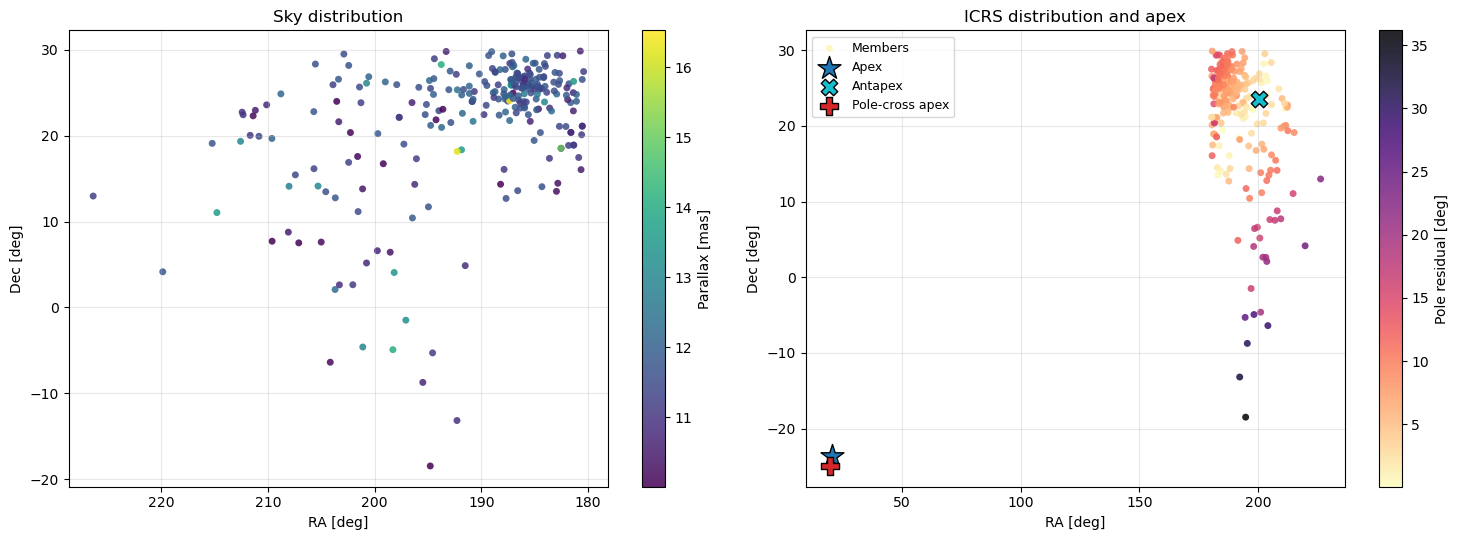

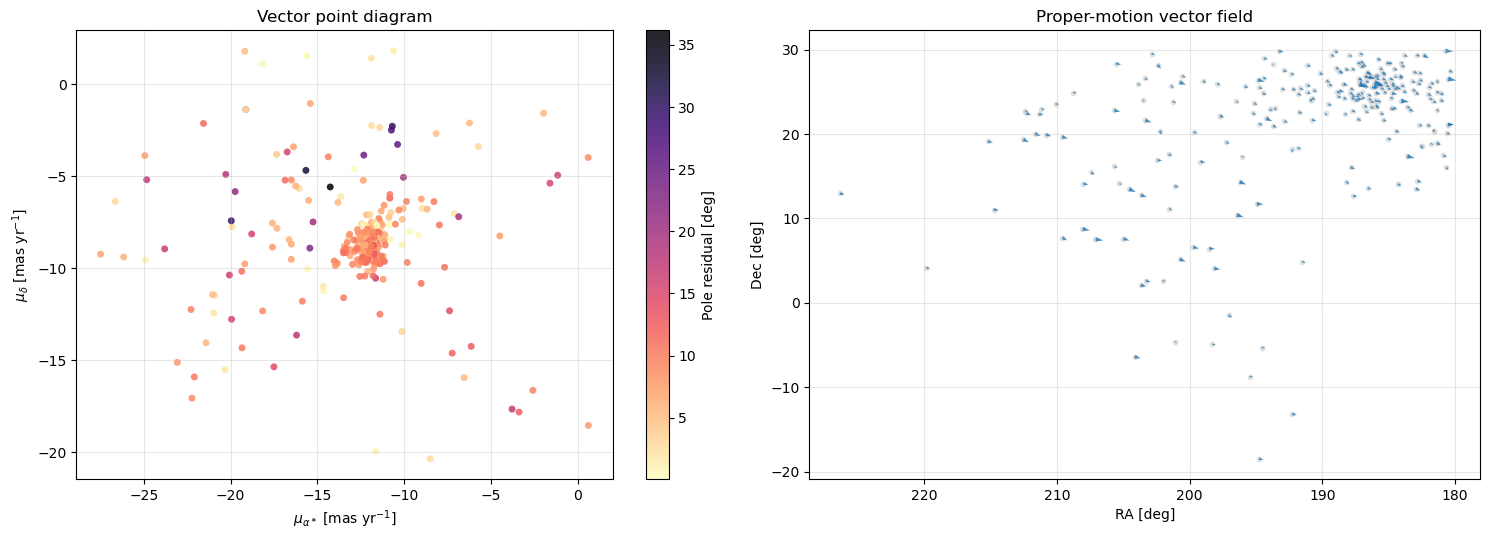

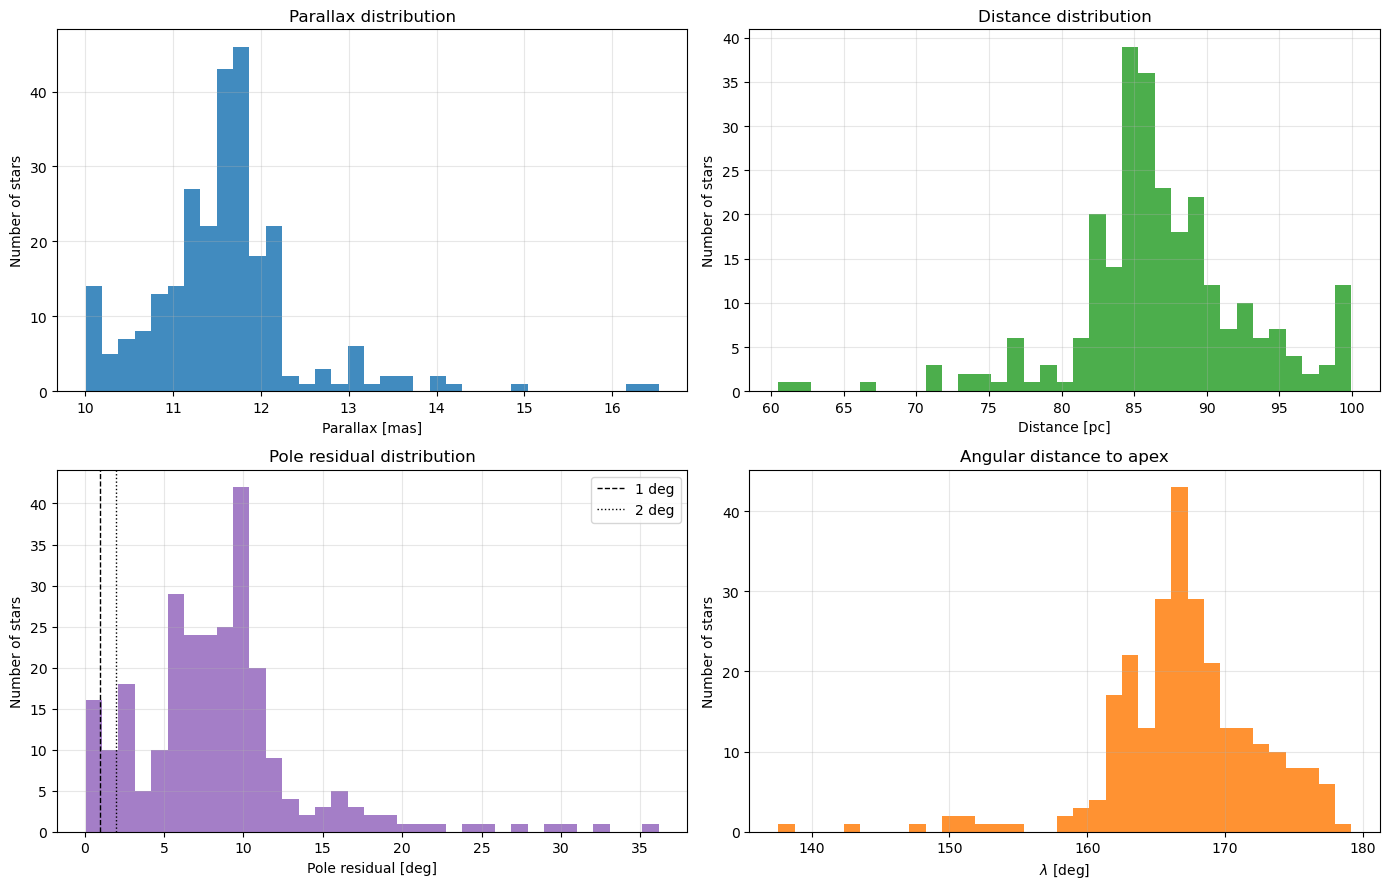

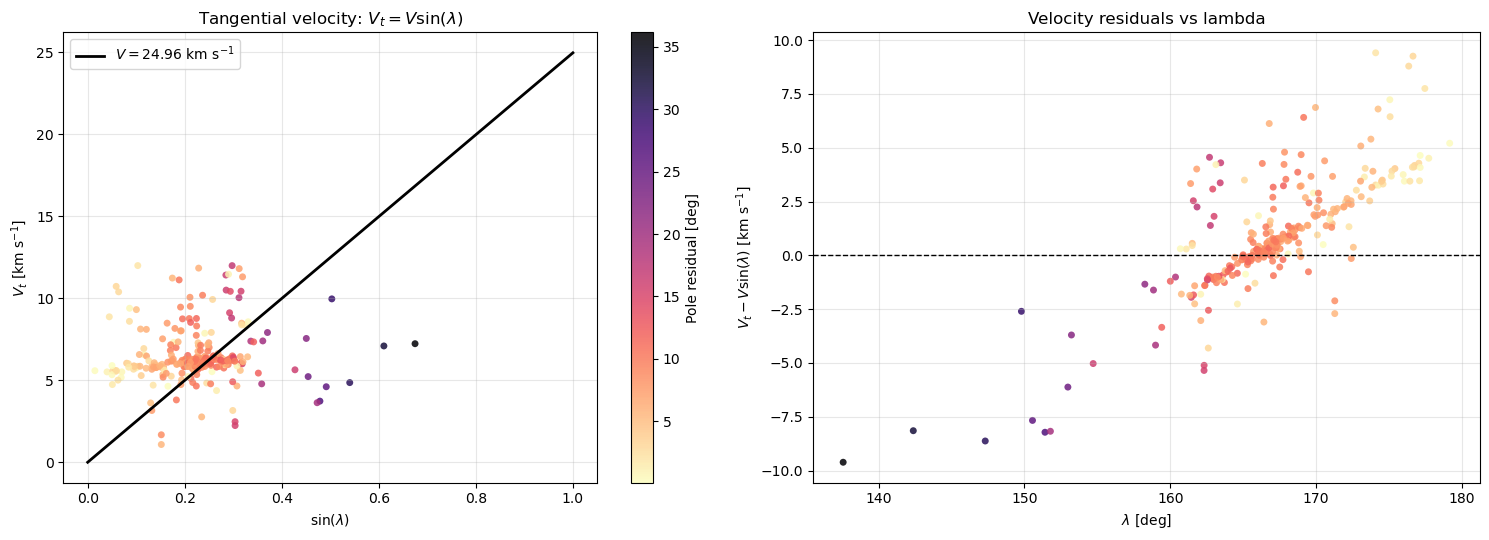

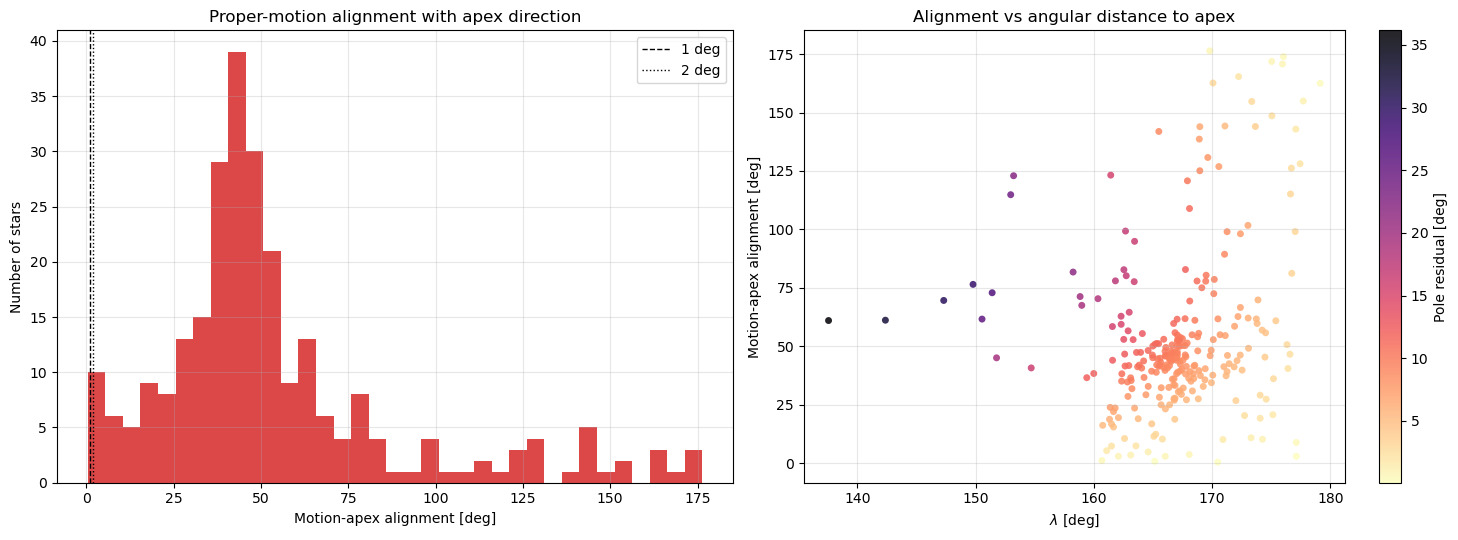

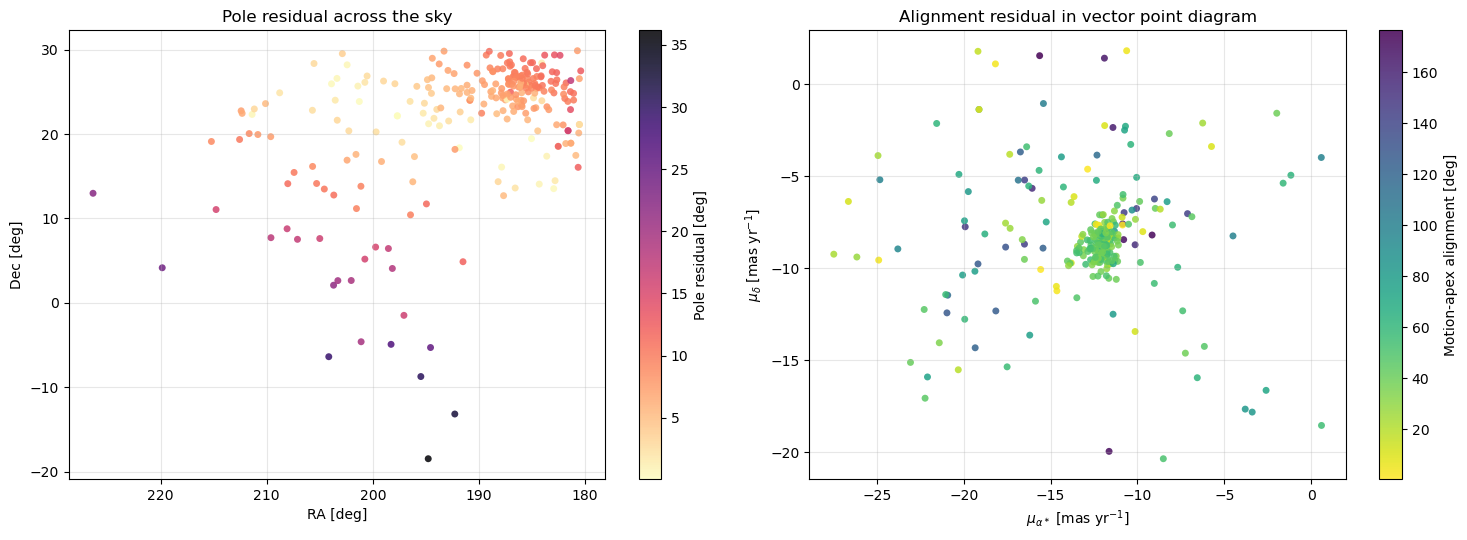

C:\Users\nicob\AppData\Local\Temp\ipykernel_19112\2148456224.py:1680: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


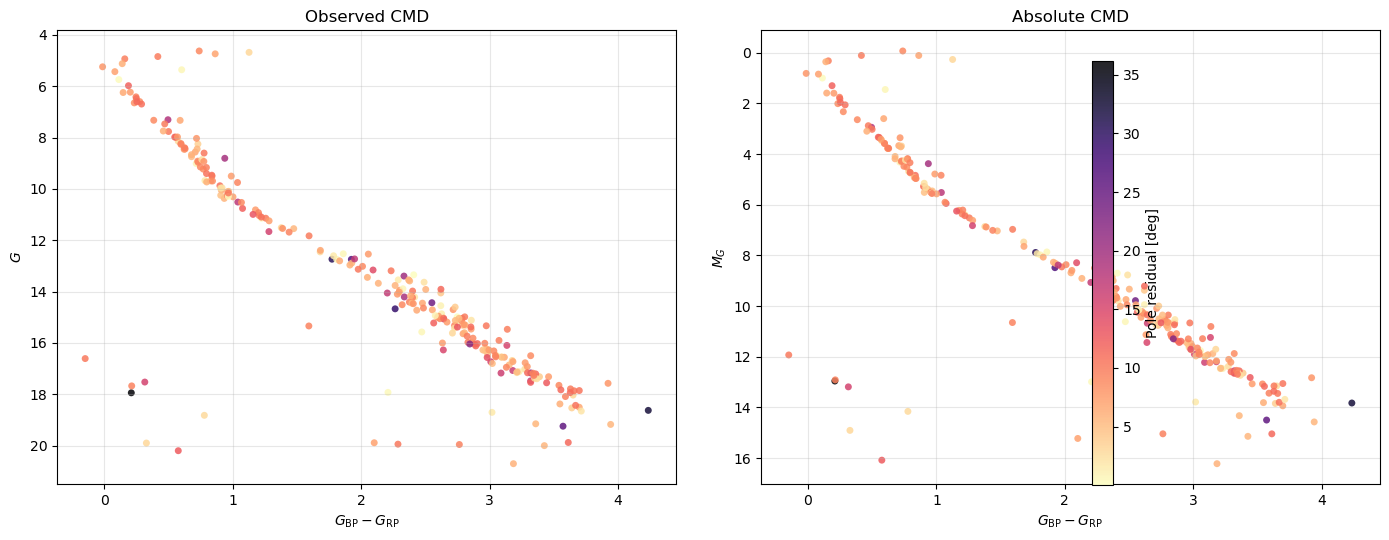


Returned objects
summary_df : global validation metrics
df_diag    : star-by-star diagnostic table
boot_df    : bootstrap apex table


In [12]:
cluster_result = result["cluster_result"]

summary_df, df_diag, boot_df = show_cluster_validation_products_icrs(
    cluster_result,
    bootstrap_n=500,
)

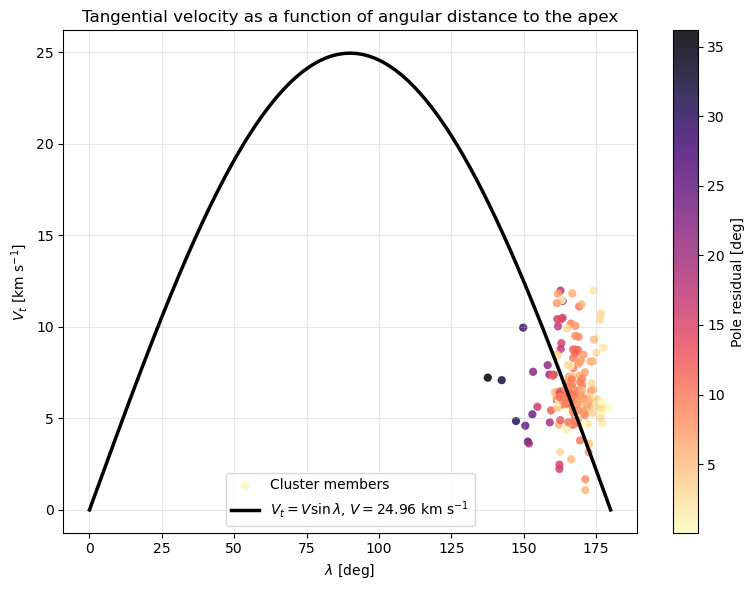

Fitted cluster speed from V_t = V sin(lambda): 24.960 km/s


In [8]:
# Datos
lambda_deg = df_diag["lambda_deg"].to_numpy(dtype=float)
vt_kms = df_diag["vt_kms"].to_numpy(dtype=float)
residual = df_diag["pole_residual_deg"].to_numpy(dtype=float)

# Ajuste V_t = V sin(lambda)
lambda_rad = np.radians(lambda_deg)
sin_lambda = np.sin(lambda_rad)

valid = (
    np.isfinite(lambda_deg)
    & np.isfinite(vt_kms)
    & np.isfinite(sin_lambda)
    & (sin_lambda > 0)
)

x = sin_lambda[valid]
y = vt_kms[valid]

V_fit = np.sum(x * y) / np.sum(x * x)

# Curva teórica ajustada
lambda_grid_deg = np.linspace(0, 180, 500)
lambda_grid_rad = np.radians(lambda_grid_deg)
vt_model = V_fit * np.sin(lambda_grid_rad)

# Gráfica
plt.figure(figsize=(8, 6))

sc = plt.scatter(
    lambda_deg,
    vt_kms,
    c=residual,
    s=35,
    cmap="magma_r",
    alpha=0.85,
    edgecolor="none",
    label="Cluster members",
)

plt.plot(
    lambda_grid_deg,
    vt_model,
    color="black",
    lw=2.5,
    label=rf"$V_t = V \sin\lambda$, $V = {V_fit:.2f}$ km s$^{{-1}}$",
)

plt.colorbar(sc, label="Pole residual [deg]")

plt.xlabel(r"$\lambda$ [deg]")
plt.ylabel(r"$V_t$ [km s$^{-1}$]")
plt.title(r"Tangential velocity as a function of angular distance to the apex")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

print(f"Fitted cluster speed from V_t = V sin(lambda): {V_fit:.3f} km/s")